# Futures Options - Comprehensive Tutorial

**Options on Futures Contracts using the Black76 Model**

This tutorial provides a comprehensive guide to pricing and analyzing options on futures, with a focus on equity index futures options.

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Futures Price Fundamentals](#2-futures-price-fundamentals)
3. [Black76 Model for Futures](#3-black76-model-for-futures)
4. [Equity Index Futures Options](#4-equity-index-futures-options)
5. [Greeks Analysis](#5-greeks-analysis)
6. [Volatility Analysis](#6-volatility-analysis)
7. [Practical Considerations](#7-practical-considerations)
8. [Advanced Topics](#8-advanced-topics)

In [1]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
import math
from datetime import date

# QuantStrata imports - Market Data
from src.marketdata.core.ids import MarketId
from src.marketdata.core.market import Market
from src.marketdata.core.interfaces import Quote
from src.marketdata.surfaces.vol_surface import FlatVolSurface
from src.marketdata.curves.term_structure import FlatZeroRateCurve

# Equity Futures Options
from src.instruments.equity.options.futures import (
    EuropeanEquityFuturesOption,
    EuropeanEquityFuturesOptionSimple,
)
from src.pricers.equity.european_b76 import (
    EquityFuturesOptionBlack76Pricer,
    EquityFuturesOptionBlack76PricerSimple,
)

# Equity Spot Options (for comparison)
from src.instruments.equity.options.vanilla import EuropeanEquityVanillaOption
from src.pricers.equity.european_bsm import EquityEuropeanVanillaBsmPricer

# Plot configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
})

print("Imports successful!")

Imports successful!


---

## 1. Introduction

### What is a Futures Option?

A **futures option** is an option to buy or sell a futures contract at a specified price. Key characteristics:

| Product | Example | Exchange | Multiplier |
|---------|---------|----------|------------|
| E-mini S&P 500 | ES options | CME | $50 |
| E-mini NASDAQ | NQ options | CME | $20 |
| Crude Oil | CL options | NYMEX | $1,000 |
| Gold | GC options | COMEX | $100 |

### Why Futures Options?

- **Leverage**: Lower margin requirements than spot
- **Liquidity**: Often more liquid than spot options
- **No dividend modeling**: Futures embed dividend expectations
- **Extended hours**: Trade almost 24/7

---

## 2. Futures Price Fundamentals

### Cost-of-Carry Model

In [2]:
# Equity Index Futures Price
def equity_futures(spot, r, q, T):
    """
    Calculate equity index futures price.
    
    F = S × exp((r - q) × T)
    
    Parameters
    ----------
    spot : float
        Spot index level
    r : float
        Risk-free rate
    q : float
        Dividend yield
    T : float
        Time to delivery in years
    """
    return spot * math.exp((r - q) * T)

# S&P 500 example
spot = 5000.0
r = 0.05       # 5% risk-free rate
q = 0.015      # 1.5% dividend yield

print("S&P 500 Futures Prices:")
print(f"Spot: {spot:,.0f}")
print(f"Rate: {r:.1%}, Dividend Yield: {q:.1%}")
print(f"\n{'Expiry':<10} {'Futures':>10} {'Basis':>10} {'Basis (%)':>12}")
print("-" * 45)

expiries = [0.25, 0.5, 1.0, 2.0]
for T in expiries:
    F = equity_futures(spot, r, q, T)
    basis = F - spot
    basis_pct = basis / spot * 100
    print(f"{T:>5.2f}Y{'':<4} {F:>10,.1f} {basis:>+10,.1f} {basis_pct:>+11.2f}%")

print(f"\nNote: Since r > q, futures trade at a premium to spot")

S&P 500 Futures Prices:
Spot: 5,000
Rate: 5.0%, Dividend Yield: 1.5%

Expiry        Futures      Basis    Basis (%)
---------------------------------------------
 0.25Y        5,043.9      +43.9       +0.88%
 0.50Y        5,088.3      +88.3       +1.77%
 1.00Y        5,178.1     +178.1       +3.56%
 2.00Y        5,362.5     +362.5       +7.25%

Note: Since r > q, futures trade at a premium to spot


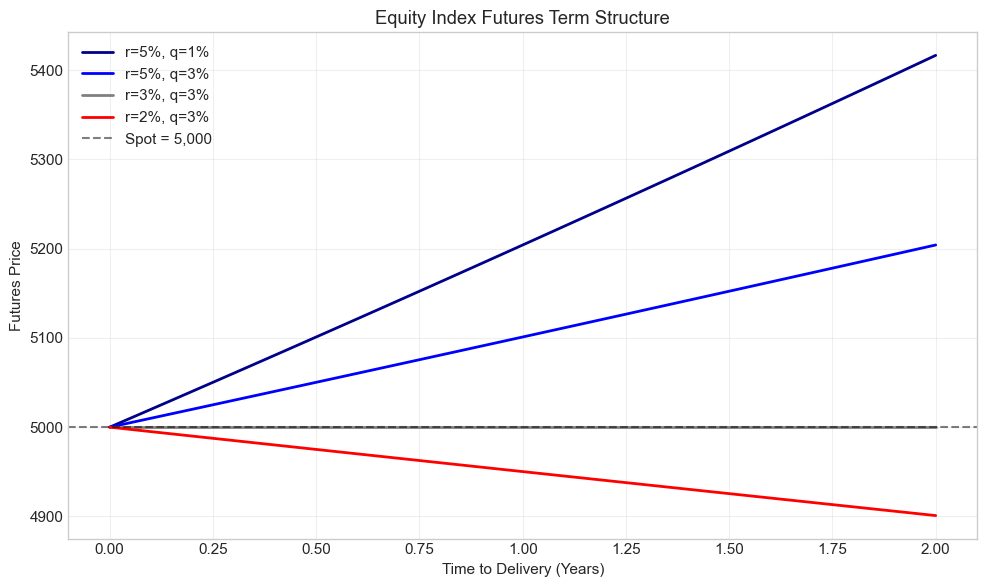

Key Insight:
  - r > q: Futures at premium (contango)
  - r < q: Futures at discount (backwardation)
  - r = q: Futures = Spot


In [3]:
# Futures basis under different rate/dividend scenarios
tenors = np.linspace(0, 2, 51)

fig, ax = plt.subplots(figsize=(10, 6))

scenarios = [
    (0.05, 0.01, 'r=5%, q=1%'),
    (0.05, 0.03, 'r=5%, q=3%'),
    (0.03, 0.03, 'r=3%, q=3%'),
    (0.02, 0.03, 'r=2%, q=3%'),
]

colors = ['darkblue', 'blue', 'gray', 'red']

for (r, q, label), color in zip(scenarios, colors):
    futures = [equity_futures(spot, r, q, T) for T in tenors]
    ax.plot(tenors, futures, color=color, label=label, linewidth=2)

ax.axhline(spot, color='black', linestyle='--', alpha=0.5, label=f'Spot = {spot:,.0f}')
ax.set_xlabel('Time to Delivery (Years)')
ax.set_ylabel('Futures Price')
ax.set_title('Equity Index Futures Term Structure')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Insight:")
print("  - r > q: Futures at premium (contango)")
print("  - r < q: Futures at discount (backwardation)")
print("  - r = q: Futures = Spot")

---

## 3. Black76 Model for Futures

### Model Dynamics

Under Black76, the futures price follows:

$$dF = \sigma F \, dW$$

**No drift**: Futures price is a martingale under the risk-neutral measure.

### Pricing Formulas

$$C = DF \cdot [F \cdot N(d_1) - K \cdot N(d_2)]$$
$$P = DF \cdot [K \cdot N(-d_2) - F \cdot N(-d_1)]$$

In [4]:
# Black76 pricing illustration
from scipy.stats import norm

def black76_price(option_type, F, K, T, r, sigma):
    """
    Black76 option price.
    
    Parameters
    ----------
    option_type : str
        'call' or 'put'
    F : float
        Futures price
    K : float
        Strike price
    T : float
        Time to expiry
    r : float
        Risk-free rate
    sigma : float
        Volatility
    """
    if T <= 0:
        if option_type == 'call':
            return max(F - K, 0)
        return max(K - F, 0)
    
    d1 = (math.log(F / K) + 0.5 * sigma**2 * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    
    df = math.exp(-r * T)
    
    if option_type == 'call':
        return df * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return df * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

# Example: E-mini S&P 500 option
spot = 5000.0
r = 0.05
q = 0.015
T = 0.25  # 3 months
sigma = 0.18

F = equity_futures(spot, r, q, T)
K = 5100  # Slightly OTM call

call_price = black76_price('call', F, K, T, r, sigma)
put_price = black76_price('put', F, K, T, r, sigma)

print("E-mini S&P 500 Option Pricing:")
print(f"  Spot:         {spot:,.0f}")
print(f"  Futures (3M): {F:,.2f}")
print(f"  Strike:       {K:,}")
print(f"  Vol:          {sigma:.0%}")
print(f"  Expiry:       {T:.2f}Y")
print(f"\n  Call Price:   {call_price:.2f} points")
print(f"  Put Price:    {put_price:.2f} points")
print(f"\n  With $50 multiplier:")
print(f"  Call Value:   ${call_price * 50:,.2f}")
print(f"  Put Value:    ${put_price * 50:,.2f}")

E-mini S&P 500 Option Pricing:
  Spot:         5,000
  Futures (3M): 5,043.94
  Strike:       5,100
  Vol:          18%
  Expiry:       0.25Y

  Call Price:   153.46 points
  Put Price:    208.82 points

  With $50 multiplier:
  Call Value:   $7,672.88
  Put Value:    $10,440.96


---

## 4. Equity Index Futures Options

### 4.1 Market Setup

In [5]:
# Define MarketIds for SPX
SPOT_ID = MarketId("EQUITY", "SPOT", "SPX", (("ccy", "USD"),))
VOL_ID = MarketId("EQUITY", "VOL", "SPX", (("ccy", "USD"),))
CURVE_ID = MarketId("IR", "CURVE", "USD.OIS", (("ccy", "USD"),))

# Create market
market = Market(
    asof="2026-01-15",
    quotes={SPOT_ID: Quote(value=5000.0)},
    curves={CURVE_ID: FlatZeroRateCurve(continuously_compounded_rate=0.05)},
    vols={VOL_ID: FlatVolSurface(sigma=0.18)},
)

# Parameters
spot = 5000.0
r = 0.05
q = 0.015
T = 0.25

futures_3m = equity_futures(spot, r, q, T)

print("Market Setup:")
print(f"  Spot Index:   {market.quote(SPOT_ID):,.0f}")
print(f"  Futures (3M): {futures_3m:,.2f}")
print(f"  Vol:          {market.vol_surface(VOL_ID).vol(T, 5000):.0%}")
print(f"  Rate:         {market.curve(CURVE_ID).zero_rate(T):.1%}")
print(f"  Div Yield:    {q:.1%} (assumed)")

Market Setup:
  Spot Index:   5,000
  Futures (3M): 5,043.94
  Vol:          18%
  Rate:         5.0%
  Div Yield:    1.5% (assumed)


### 4.2 Pricing with QuantStrata

In [6]:
# Create E-mini style options
call_option = EuropeanEquityFuturesOption(
    ticker="SPX",
    option_type="call",
    strike=5100.0,
    expiry=0.25,              # 3 months
    futures_expiry=0.25,
    notional=50.0,            # E-mini multiplier
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    curve_id=CURVE_ID,
    dividend_yield=0.015,
)

put_option = EuropeanEquityFuturesOption(
    ticker="SPX",
    option_type="put",
    strike=5100.0,
    expiry=0.25,
    futures_expiry=0.25,
    notional=50.0,
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    curve_id=CURVE_ID,
    dividend_yield=0.015,
)

# Price
pricer = EquityFuturesOptionBlack76Pricer()

call_pv = pricer.price(call_option, market)
put_pv = pricer.price(put_option, market)

print("E-mini S&P 500 Futures Options (K=5100, T=3M):")
print(f"  Call PV: ${call_pv:,.2f}")
print(f"  Put PV:  ${put_pv:,.2f}")

# Put-call parity
df = math.exp(-r * T)
expected_diff = df * (futures_3m - 5100) * 50
actual_diff = call_pv - put_pv

print(f"\nPut-Call Parity:")
print(f"  C - P = ${actual_diff:,.2f}")
print(f"  DF(F-K) × Notional = ${expected_diff:,.2f}")

E-mini S&P 500 Futures Options (K=5100, T=3M):
  Call PV: $7,672.88
  Put PV:  $10,440.96

Put-Call Parity:
  C - P = $-2,768.08
  DF(F-K) × Notional = $-2,768.08


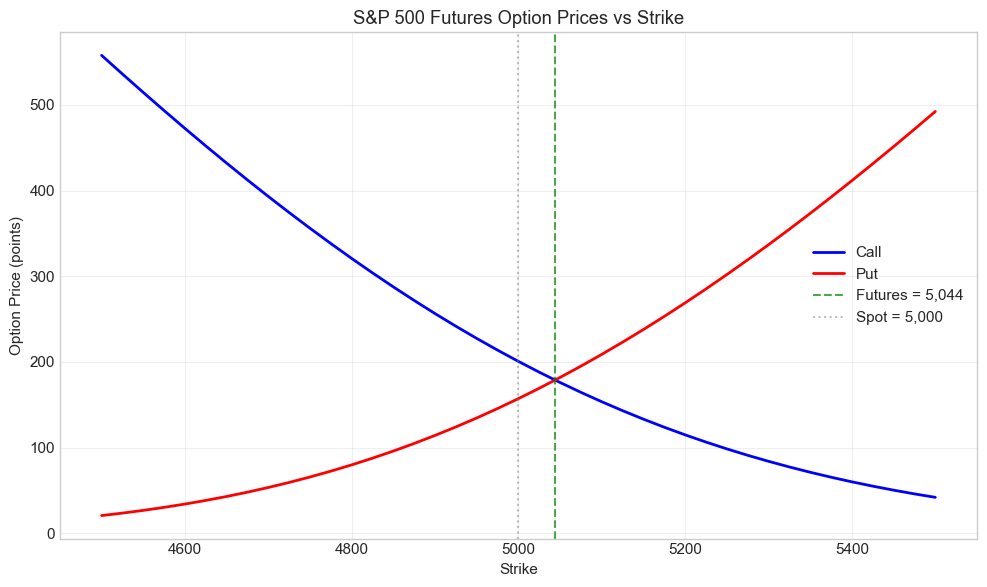

In [7]:
# Price across strikes
strikes = np.linspace(4500, 5500, 41)
call_prices = []
put_prices = []

for K in strikes:
    call = EuropeanEquityFuturesOption(
        ticker="SPX", option_type="call", strike=K, expiry=0.25, futures_expiry=0.25,
        notional=1.0, spot_id=SPOT_ID, vol_id=VOL_ID, curve_id=CURVE_ID, dividend_yield=0.015,
    )
    put = EuropeanEquityFuturesOption(
        ticker="SPX", option_type="put", strike=K, expiry=0.25, futures_expiry=0.25,
        notional=1.0, spot_id=SPOT_ID, vol_id=VOL_ID, curve_id=CURVE_ID, dividend_yield=0.015,
    )
    call_prices.append(pricer.price(call, market))
    put_prices.append(pricer.price(put, market))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(strikes, call_prices, 'b-', label='Call', linewidth=2)
ax.plot(strikes, put_prices, 'r-', label='Put', linewidth=2)
ax.axvline(futures_3m, color='green', linestyle='--', alpha=0.7, label=f'Futures = {futures_3m:,.0f}')
ax.axvline(spot, color='gray', linestyle=':', alpha=0.5, label=f'Spot = {spot:,.0f}')

ax.set_xlabel('Strike')
ax.set_ylabel('Option Price (points)')
ax.set_title('S&P 500 Futures Option Prices vs Strike')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Greeks Analysis

### 5.1 Delta: Futures vs Spot

In [8]:
# Get Greeks
call_greeks = pricer.greeks(call_option, market)
put_greeks = pricer.greeks(put_option, market)

print("Greeks for Futures Options (K=5100, T=3M, Notional=$50):")
print(f"\n{'Greek':<18} {'Call':>12} {'Put':>12}")
print("-" * 45)

for greek in ['delta_futures', 'delta_spot', 'gamma', 'vega', 'theta', 'rho']:
    call_val = call_greeks[greek]
    put_val = put_greeks[greek]
    print(f"{greek:<18} {call_val:>12,.2f} {put_val:>12,.2f}")

Greeks for Futures Options (K=5100, T=3M, Notional=$50):

Greek                      Call          Put
---------------------------------------------
delta_futures             23.16       -26.22
delta_spot                23.36       -26.45
gamma                      0.04         0.04
vega                  49,530.98    49,530.98
theta                -17,447.51   -17,309.10
rho                   -1,918.22    -2,610.24


In [9]:
# Delta relationship
print("Understanding Delta:")
print(f"\n  Delta Futures: {call_greeks['delta_futures']:.2f}")
print(f"  Delta Spot:    {call_greeks['delta_spot']:.2f}")

expected_ratio = math.exp((r - q) * T)
actual_ratio = call_greeks['delta_spot'] / call_greeks['delta_futures']

print(f"\n  Ratio (Spot/Futures): {actual_ratio:.4f}")
print(f"  Expected:             {expected_ratio:.4f} = exp((r-q)×T)")
print(f"\nInterpretation:")
print(f"  To hedge with spot, need slightly MORE shares than futures delta")
print(f"  Because spot grows to futures level by expiry")

Understanding Delta:

  Delta Futures: 23.16
  Delta Spot:    23.36

  Ratio (Spot/Futures): 1.0088
  Expected:             1.0088 = exp((r-q)×T)

Interpretation:
  To hedge with spot, need slightly MORE shares than futures delta
  Because spot grows to futures level by expiry


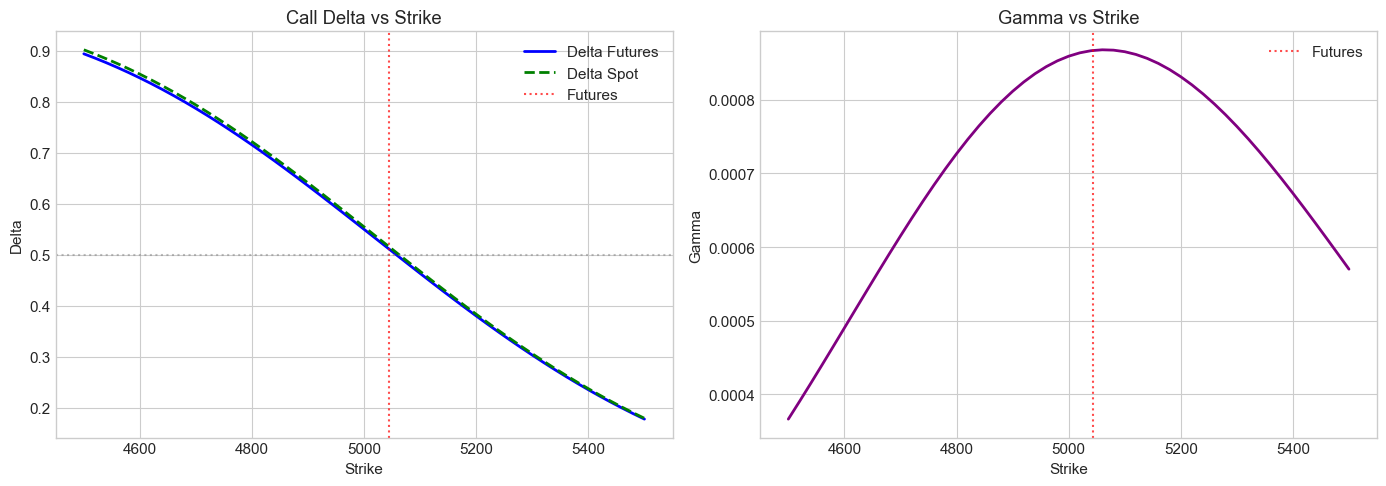

Max Gamma at K=5060 (near ATM forward 5044)


In [10]:
# Delta and Gamma across strikes
strikes = np.linspace(4500, 5500, 51)
call_delta_fwd = []
call_delta_spot = []
gammas = []

for K in strikes:
    call = EuropeanEquityFuturesOption(
        ticker="SPX", option_type="call", strike=K, expiry=0.25, futures_expiry=0.25,
        notional=1.0, spot_id=SPOT_ID, vol_id=VOL_ID, curve_id=CURVE_ID, dividend_yield=0.015,
    )
    g = pricer.greeks(call, market)
    call_delta_fwd.append(g['delta_futures'])
    call_delta_spot.append(g['delta_spot'])
    gammas.append(g['gamma'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(strikes, call_delta_fwd, 'b-', label='Delta Futures', linewidth=2)
ax.plot(strikes, call_delta_spot, 'g--', label='Delta Spot', linewidth=2)
ax.axvline(futures_3m, color='red', linestyle=':', alpha=0.7, label=f'Futures')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike')
ax.set_ylabel('Delta')
ax.set_title('Call Delta vs Strike')
ax.legend()

ax = axes[1]
ax.plot(strikes, gammas, 'purple', linewidth=2)
ax.axvline(futures_3m, color='red', linestyle=':', alpha=0.7, label='Futures')
ax.set_xlabel('Strike')
ax.set_ylabel('Gamma')
ax.set_title('Gamma vs Strike')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Max Gamma at K={strikes[np.argmax(gammas)]:.0f} (near ATM forward {futures_3m:.0f})")

### 5.2 Vega and Theta

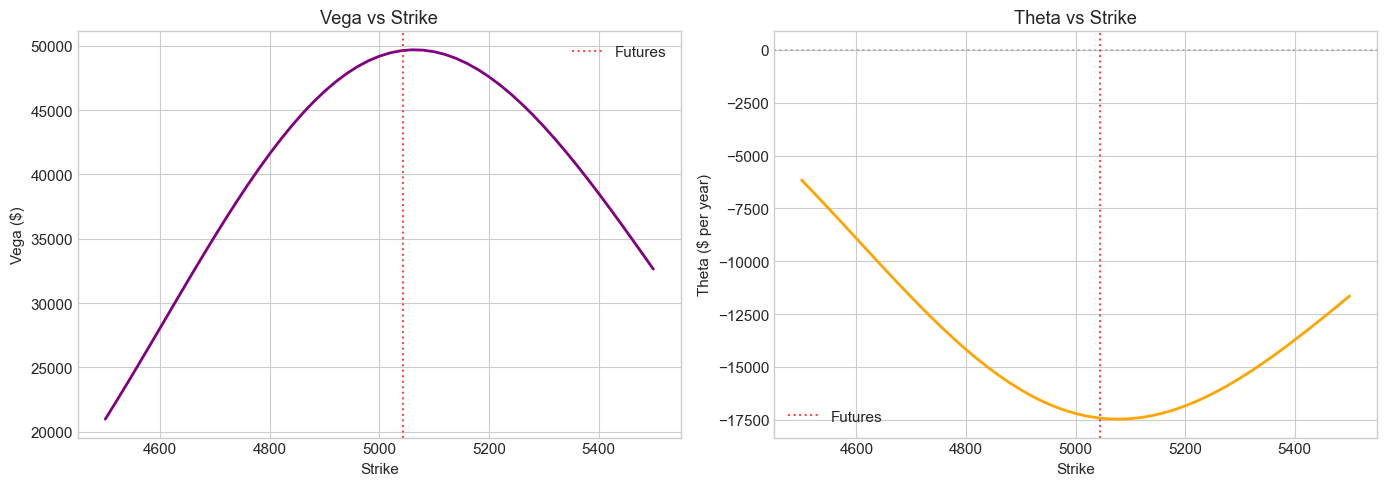

Key Observations:
  - Vega peaks at ATM (maximum vol sensitivity)
  - Theta most negative at ATM (maximum time decay)


In [11]:
# Vega across strikes
strikes = np.linspace(4500, 5500, 51)
vegas = []
thetas = []

for K in strikes:
    call = EuropeanEquityFuturesOption(
        ticker="SPX", option_type="call", strike=K, expiry=0.25, futures_expiry=0.25,
        notional=50.0, spot_id=SPOT_ID, vol_id=VOL_ID, curve_id=CURVE_ID, dividend_yield=0.015,
    )
    g = pricer.greeks(call, market)
    vegas.append(g['vega'])
    thetas.append(g['theta'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(strikes, vegas, 'purple', linewidth=2)
ax.axvline(futures_3m, color='red', linestyle=':', alpha=0.7, label='Futures')
ax.set_xlabel('Strike')
ax.set_ylabel('Vega ($)')
ax.set_title('Vega vs Strike')
ax.legend()

ax = axes[1]
ax.plot(strikes, thetas, 'orange', linewidth=2)
ax.axvline(futures_3m, color='red', linestyle=':', alpha=0.7, label='Futures')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike')
ax.set_ylabel('Theta ($ per year)')
ax.set_title('Theta vs Strike')
ax.legend()

plt.tight_layout()
plt.show()

print("Key Observations:")
print("  - Vega peaks at ATM (maximum vol sensitivity)")
print("  - Theta most negative at ATM (maximum time decay)")

---

## 6. Volatility Analysis

### 6.1 Price Sensitivity to Vol

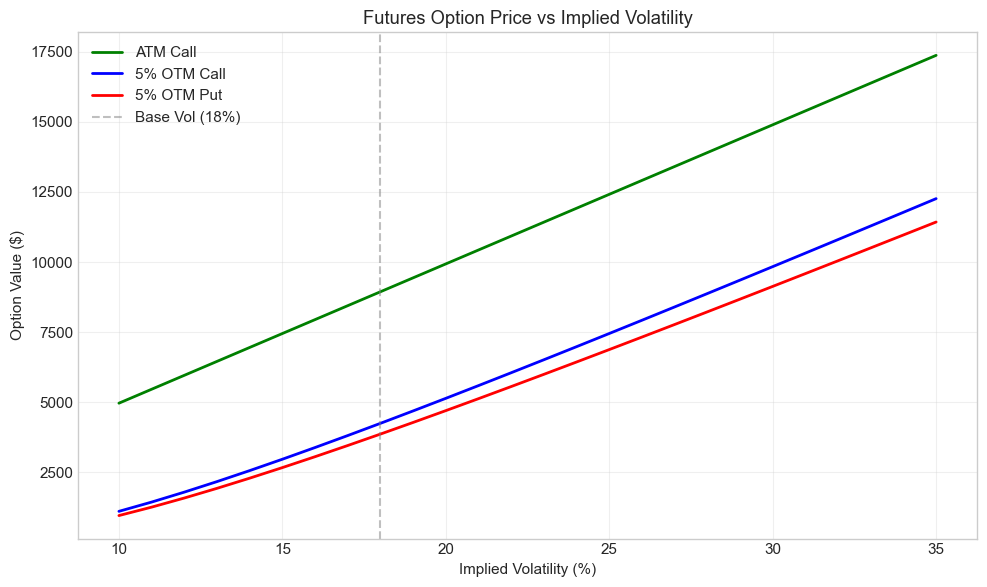

In [12]:
# Price sensitivity to volatility
vols = np.linspace(0.10, 0.35, 26)
atm_prices = []
otm_call_prices = []
otm_put_prices = []

for sigma in vols:
    mkt = Market(
        asof="2026-01-15",
        quotes={SPOT_ID: Quote(value=5000.0)},
        curves={CURVE_ID: FlatZeroRateCurve(continuously_compounded_rate=0.05)},
        vols={VOL_ID: FlatVolSurface(sigma=sigma)},
    )
    
    # ATM
    atm = EuropeanEquityFuturesOption(
        ticker="SPX", option_type="call", strike=futures_3m, expiry=0.25, futures_expiry=0.25,
        notional=50.0, spot_id=SPOT_ID, vol_id=VOL_ID, curve_id=CURVE_ID, dividend_yield=0.015,
    )
    atm_prices.append(pricer.price(atm, mkt))
    
    # OTM Call (5% OTM)
    otm_c = EuropeanEquityFuturesOption(
        ticker="SPX", option_type="call", strike=futures_3m * 1.05, expiry=0.25, futures_expiry=0.25,
        notional=50.0, spot_id=SPOT_ID, vol_id=VOL_ID, curve_id=CURVE_ID, dividend_yield=0.015,
    )
    otm_call_prices.append(pricer.price(otm_c, mkt))
    
    # OTM Put (5% OTM)
    otm_p = EuropeanEquityFuturesOption(
        ticker="SPX", option_type="put", strike=futures_3m * 0.95, expiry=0.25, futures_expiry=0.25,
        notional=50.0, spot_id=SPOT_ID, vol_id=VOL_ID, curve_id=CURVE_ID, dividend_yield=0.015,
    )
    otm_put_prices.append(pricer.price(otm_p, mkt))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(vols * 100, atm_prices, 'g-', label='ATM Call', linewidth=2)
ax.plot(vols * 100, otm_call_prices, 'b-', label='5% OTM Call', linewidth=2)
ax.plot(vols * 100, otm_put_prices, 'r-', label='5% OTM Put', linewidth=2)
ax.axvline(18, color='gray', linestyle='--', alpha=0.5, label='Base Vol (18%)')

ax.set_xlabel('Implied Volatility (%)')
ax.set_ylabel('Option Value ($)')
ax.set_title('Futures Option Price vs Implied Volatility')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Term Structure Effect

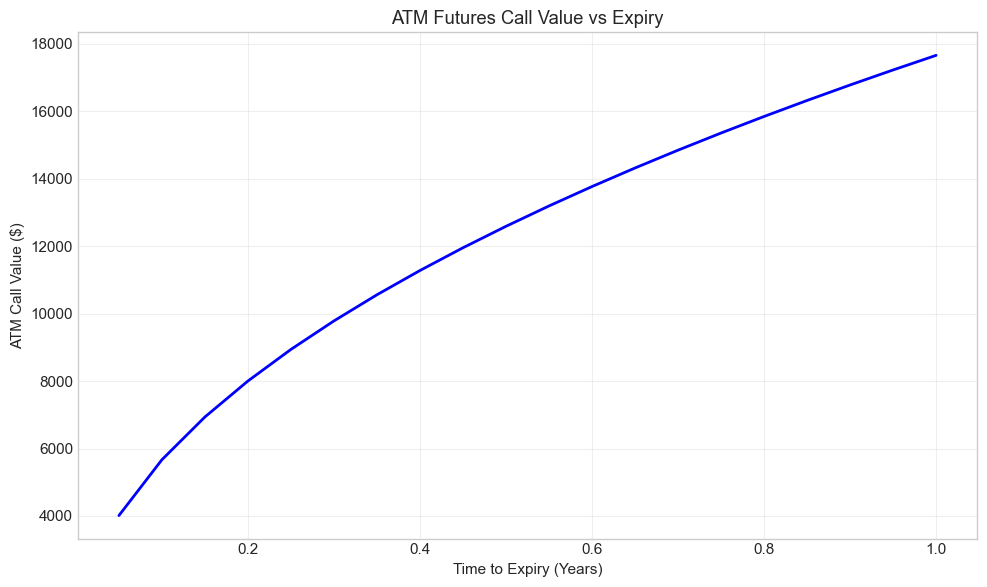

Note: ATM option value increases with √T (vega effect dominates)


In [13]:
# ATM option prices across expiries
expiries = np.linspace(0.05, 1.0, 20)
atm_by_expiry = []

for T in expiries:
    F_T = equity_futures(spot, r, q, T)
    opt = EuropeanEquityFuturesOption(
        ticker="SPX", option_type="call", strike=F_T, expiry=T, futures_expiry=T,
        notional=50.0, spot_id=SPOT_ID, vol_id=VOL_ID, curve_id=CURVE_ID, dividend_yield=0.015,
    )
    atm_by_expiry.append(pricer.price(opt, market))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(expiries, atm_by_expiry, 'b-', linewidth=2)
ax.set_xlabel('Time to Expiry (Years)')
ax.set_ylabel('ATM Call Value ($)')
ax.set_title('ATM Futures Call Value vs Expiry')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: ATM option value increases with √T (vega effect dominates)")

---

## 7. Practical Considerations

### 7.1 Contract Specifications

In [14]:
print("Common Equity Index Futures Options:")
print(f"\n{'Product':<25} {'Symbol':<10} {'Multiplier':>12} {'Tick Size':>12}")
print("-" * 62)

products = [
    ("E-mini S&P 500", "ES", "$50", "0.25 pts"),
    ("Micro E-mini S&P 500", "MES", "$5", "0.25 pts"),
    ("E-mini NASDAQ-100", "NQ", "$20", "0.25 pts"),
    ("E-mini Russell 2000", "RTY", "$50", "0.10 pts"),
    ("E-mini Dow", "YM", "$5", "1.00 pts"),
]

for name, symbol, mult, tick in products:
    print(f"{name:<25} {symbol:<10} {mult:>12} {tick:>12}")

Common Equity Index Futures Options:

Product                   Symbol       Multiplier    Tick Size
--------------------------------------------------------------
E-mini S&P 500            ES                  $50     0.25 pts
Micro E-mini S&P 500      MES                  $5     0.25 pts
E-mini NASDAQ-100         NQ                  $20     0.25 pts
E-mini Russell 2000       RTY                 $50     0.10 pts
E-mini Dow                YM                   $5     1.00 pts


In [15]:
# Calculate P&L for different scenarios
print("\nP&L Analysis for Long Call Position:")
print(f"\nPosition: Long 1 ES 5100 Call @ ${call_pv:.2f}")
print(f"\n{'Scenario':<30} {'Futures':>10} {'P&L':>12}")
print("-" * 55)

scenarios = [
    ("Futures +5%", futures_3m * 1.05),
    ("Futures +2%", futures_3m * 1.02),
    ("Futures unchanged", futures_3m),
    ("Futures -2%", futures_3m * 0.98),
    ("Futures -5%", futures_3m * 0.95),
]

for desc, new_futures in scenarios:
    # Intrinsic at expiry
    payoff = max(new_futures - 5100, 0) * 50
    pnl = payoff - call_pv
    print(f"{desc:<30} {new_futures:>10,.0f} ${pnl:>10,.2f}")


P&L Analysis for Long Call Position:

Position: Long 1 ES 5100 Call @ $7672.88

Scenario                          Futures          P&L
-------------------------------------------------------
Futures +5%                         5,296 $  2,134.08
Futures +2%                         5,145 $ -5,431.84
Futures unchanged                   5,044 $ -7,672.88
Futures -2%                         4,943 $ -7,672.88
Futures -5%                         4,792 $ -7,672.88


---

## 8. Advanced Topics

### 8.1 Simple Pricer (Direct Futures Input)

In [16]:
# When futures price is directly observable
simple_call = EuropeanEquityFuturesOptionSimple(
    ticker="ES",
    option_type="call",
    strike=5100.0,
    expiry=0.25,
    futures_price=futures_3m,
    vol=0.18,
    discount_factor=math.exp(-0.05 * 0.25),
    notional=50.0,
)

simple_pricer = EquityFuturesOptionBlack76PricerSimple()
simple_pv = simple_pricer.price(simple_call)
simple_greeks = simple_pricer.greeks(simple_call)

print("Simple Pricer (Direct Futures Input):")
print(f"  Futures: {futures_3m:,.2f}")
print(f"  Strike:  5100")
print(f"  Vol:     18%")
print(f"\n  Call PV: ${simple_pv:,.2f}")
print(f"\n  Comparison with full pricer: ${call_pv:,.2f}")
print(f"  Match: {np.isclose(simple_pv, call_pv, rtol=1e-6)}")

print(f"\nGreeks:")
for greek, val in simple_greeks.items():
    print(f"  {greek}: {val:,.2f}")

Simple Pricer (Direct Futures Input):
  Futures: 5,043.94
  Strike:  5100
  Vol:     18%

  Call PV: $7,672.88

  Comparison with full pricer: $7,672.88
  Match: True

Greeks:
  delta: 23.16
  gamma: 0.04
  vega: 49,530.98
  theta: -17,447.51
  rho: -1,918.22


### 8.2 Comparison with Spot Options

In [17]:
# Create equivalent spot option
spot_call = EuropeanEquityVanillaOption(
    ticker="SPX",
    option_type="call",
    strike=5100.0,
    expiry=0.25,
    notional=50.0,
    dividend_yield=0.015,
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    curve_id=CURVE_ID,
)

bsm_pricer = EquityEuropeanVanillaBsmPricer()

spot_call_pv = bsm_pricer.price(spot_call, market)
spot_greeks = bsm_pricer.greeks(spot_call, market)

print("Futures Option vs Spot Option (K=5100, T=3M):")
print(f"\n{'Metric':<15} {'Futures Opt':>15} {'Spot Opt':>15}")
print("-" * 50)
print(f"{'PV':<15} ${call_pv:>13,.2f} ${spot_call_pv:>13,.2f}")
print(f"{'Delta':<15} {call_greeks['delta_spot']:>15,.2f} {spot_greeks['delta']:>15,.2f}")
print(f"{'Gamma':<15} {call_greeks['gamma']:>15,.4f} {spot_greeks['gamma']:>15,.4f}")
print(f"{'Vega':<15} ${call_greeks['vega']:>13,.2f} ${spot_greeks['vega']:>13,.2f}")

print(f"\nPrices should be identical (no-arbitrage)")
print(f"Difference: ${abs(call_pv - spot_call_pv):.4f}")

Futures Option vs Spot Option (K=5100, T=3M):

Metric              Futures Opt        Spot Opt
--------------------------------------------------
PV              $     7,672.88 $     7,672.88
Delta                     23.36           23.36
Gamma                    0.0433          0.0440
Vega            $    49,530.98 $    49,530.98

Prices should be identical (no-arbitrage)
Difference: $0.0000


---

## Summary

### Key Concepts

| Concept | Formula/Description |
|---------|--------------------|
| **Futures Price** | F = S × exp((r - q) × T) |
| **Black76** | No-drift model for futures |
| **Delta Futures** | dV/dF (sensitivity to futures) |
| **Delta Spot** | = Delta Futures × exp((r-q)×T) |
| **Multiplier** | E-mini S&P = $50 per point |

### Best Practices

1. **Use observed futures prices** when available (avoid model risk)
2. **Delta hedge with futures** (no financing cost)
3. **Monitor roll dates** for expiring contracts
4. **Consider liquidity** - often better than OTC options

### Related Documentation

- [Black76 Model](../../reference/models/black76.md)
- [Futures Options Guide](../../guides/instruments/futures_options.md)
- [Equity Options Pricing](../pricing/equity_options_pricing.ipynb)